#Online Shopping Sales Data Analysis Using Python
###IBM Industrial Training Mini Project
**Domain:**Data Handling and Visualization Using Python
**Tools:**Python,Pandas,Numpy,Matplotlib,Seaborn


Libraries Install/**Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


**Make Dataset:**

In [2]:
import random

random.seed(42)
np.random.seed(42)

n = 1000

dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")

categories = [
    "Electronics",
    "Clothing",
    "Home & Kitchen",
    "Beauty",
    "Sports",
    "Books"
]

products = {
    "Electronics": [
        "Wireless Headphones", "Smart Watch",
        "Bluetooth Speaker", "Power Bank",
        "Keyboard", "Mouse"
    ],

    "Clothing": [
        "T-Shirt", "Jeans",
        "Jacket", "Sneakers",
        "Dress", "Hoodie"
    ],

    "Home & Kitchen": [
        "Coffee Maker", "Cookware Set",
        "Mixer Grinder", "Bedsheet",
        "Storage Box", "Water Bottle"
    ],

    "Beauty": [
        "Face Wash", "Moisturizer",
        "Perfume", "Lipstick",
        "Sunscreen", "Hair Dryer"
    ],

    "Sports": [
        "Yoga Mat", "Football",
        "Cricket Bat", "Dumbbells",
        "Running Shoes", "Skipping Rope"
    ],

    "Books": [
        "Python Basics", "Data Science Guide",
        "Fiction Novel", "Business Book",
        "Self Help Book", "History Book"
    ]
}

cities = [
    "Kolkata", "Delhi", "Mumbai",
    "Bengaluru", "Hyderabad",
    "Chennai", "Pune",
    "Ahmedabad", "Jaipur", "Lucknow"
]

payments = [
    "UPI",
    "Credit Card",
    "Debit Card",
    "Cash on Delivery",
    "Net Banking"
]

genders = ["Male", "Female"]

rows = []

for i in range(1, n + 1):

    category = random.choices(
        categories,
        weights=[24, 20, 18, 12, 14, 12]
    )[0]

    product = random.choice(products[category])

    quantity = random.choices(
        [1, 2, 3, 4, 5],
        weights=[55, 25, 12, 6, 2]
    )[0]

    price_ranges = {
        "Electronics": (700, 18000),
        "Clothing": (400, 3500),
        "Home & Kitchen": (500, 7000),
        "Beauty": (250, 2500),
        "Sports": (400, 6000),
        "Books": (200, 1500)
    }

    low, high = price_ranges[category]

    unit_price = round(
        random.uniform(low, high) / 10
    ) * 10

    discount = random.choice([0, 5, 10, 15, 20])

    total_amount = round(
        quantity * unit_price *
        (1 - discount / 100),
        2
    )

    rows.append([
        f"ORD{i:04d}",
        random.choice(dates),
        random.choice(cities),
        random.choice(genders),
        random.randint(18, 55),
        category,
        product,
        quantity,
        unit_price,
        discount,
        total_amount,
        random.choice(payments),
        random.choice([
            "Delivered",
            "Delivered",
            "Delivered",
            "Cancelled",
            "Returned"
        ])
    ])

df = pd.DataFrame(
    rows,
    columns=[
        "Order_ID",
        "Order_Date",
        "City",
        "Gender",
        "Age",
        "Category",
        "Product",
        "Quantity",
        "Unit_Price",
        "Discount_Percent",
        "Total_Amount",
        "Payment_Method",
        "Order_Status"
    ]
)

print("Dataset created successfully!")

Dataset created successfully!


**Understanding The Dataset:**

In [3]:
df.head()

,Order_ID,Order_Date,City,Gender,Age,Category,Product,Quantity,Unit_Price,Discount_Percent,Total_Amount,Payment_Method,Order_Status
0,ORD0001,2025-02-22,Jaipur,Male,55,Beauty,Face Wash,2,800,5,1520.0,Cash on Delivery,Delivered
1,ORD0002,2025-04-12,Jaipur,Female,32,Electronics,Smart Watch,1,11110,20,8888.0,Cash on Delivery,Returned
2,ORD0003,2025-06-24,Hyderabad,Male,31,Clothing,T-Shirt,2,890,15,1513.0,Debit Card,Delivered
3,ORD0004,2025-01-23,Ahmedabad,Male,42,Electronics,Wireless Headphones,1,6650,10,5985.0,UPI,Returned
4,ORD0005,2025-04-09,Delhi,Male,32,Clothing,Hoodie,2,3070,20,4912.0,Debit Card,Delivered


In [4]:
df.shape

(1000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          1000 non-null   object        
 1   Order_Date        1000 non-null   datetime64[ns]
 2   City              1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Category          1000 non-null   object        
 6   Product           1000 non-null   object        
 7   Quantity          1000 non-null   int64         
 8   Unit_Price        1000 non-null   int64         
 9   Discount_Percent  1000 non-null   int64         
 10  Total_Amount      1000 non-null   float64       
 11  Payment_Method    1000 non-null   object        
 12  Order_Status      1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(7)
memory usage: 101.7+ KB


In [6]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Discount_Percent,Total_Amount
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-06 01:00:28.800000256,36.565000,1.687000,3997.740000,10.055000,6005.084500
min,2025-01-01 00:00:00,18.000000,1.000000,200.000000,0.000000,180.000000
25%,2025-04-07 00:00:00,27.000000,1.000000,1220.000000,5.000000,1564.000000
50%,2025-07-13 12:00:00,36.000000,1.000000,2480.000000,10.000000,3080.000000
75%,2025-10-04 06:00:00,46.000000,2.000000,4985.000000,15.000000,6962.875000
max,2025-12-31 00:00:00,55.000000,5.000000,17940.000000,20.000000,80085.000000
std,NaN,11.161916,0.966419,4111.270489,7.005073,8184.423069


In [7]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
City,0
Gender,0
Age,0
Category,0
Product,0
Quantity,0
Unit_Price,0
Discount_Percent,0


**Data Cleaning:**

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("Order_Date converted successfully!")
print(df["Order_Date"].dtype)

Order_Date converted successfully!
datetime64[ns]


In [10]:
df = df.drop_duplicates()

print("Duplicate rows removed.")
print("Current dataset shape:", df.shape)

Duplicate rows removed.
Current dataset shape: (1000, 13)


In [11]:
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())
print("Invalid Unit Price:", (df["Unit_Price"] <= 0).sum())
print("Invalid Total Amount:", (df["Total_Amount"] < 0).sum())

Invalid Quantity: 0
Invalid Unit Price: 0
Invalid Total Amount: 0


In [12]:
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

df.head()

,Order_ID,Order_Date,City,Gender,Age,Category,Product,Quantity,Unit_Price,Discount_Percent,Total_Amount,Payment_Method,Order_Status,Month
0,ORD0001,2025-02-22,Jaipur,Male,55,Beauty,Face Wash,2,800,5,1520.0,Cash on Delivery,Delivered,2025-02
1,ORD0002,2025-04-12,Jaipur,Female,32,Electronics,Smart Watch,1,11110,20,8888.0,Cash on Delivery,Returned,2025-04
2,ORD0003,2025-06-24,Hyderabad,Male,31,Clothing,T-Shirt,2,890,15,1513.0,Debit Card,Delivered,2025-06
3,ORD0004,2025-01-23,Ahmedabad,Male,42,Electronics,Wireless Headphones,1,6650,10,5985.0,UPI,Returned,2025-01
4,ORD0005,2025-04-09,Delhi,Male,32,Clothing,Hoodie,2,3070,20,4912.0,Debit Card,Delivered,2025-04


In [13]:
total_orders = df["Order_ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 1000


In [14]:
total_revenue = df["Total_Amount"].sum()

print("Total Revenue: ₹", round(total_revenue, 2))

Total Revenue: ₹ 6005084.5


In [15]:
average_order_value = df["Total_Amount"].mean()

print("Average Order Value: ₹", round(average_order_value, 2))

Average Order Value: ₹ 6005.08


In [16]:
total_units = df["Quantity"].sum()

print("Total Units Sold:", total_units)

Total Units Sold: 1687


In [ ]:
**Sales Performance Analysis:**

In [17]:
print("========== SALES KPI ==========")

print("Total Orders       :", total_orders)
print("Total Revenue      : ₹", round(total_revenue, 2))
print("Average Order Value: ₹", round(average_order_value, 2))
print("Total Units Sold   :", total_units)

print("===============================")

========== SALES KPI ==========
Total Orders       : 1000
Total Revenue      : ₹ 6005084.5
Average Order Value: ₹ 6005.08
Total Units Sold   : 1687


**Category-wise Sales Analysis:**

In [18]:
category_sales = (
    df.groupby("Category")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Electronics       3487238.0
Home & Kitchen     963122.5
Sports             583859.0
Clothing           542414.0
Beauty             254790.0
Books              173661.0
Name: Total_Amount, dtype: float64


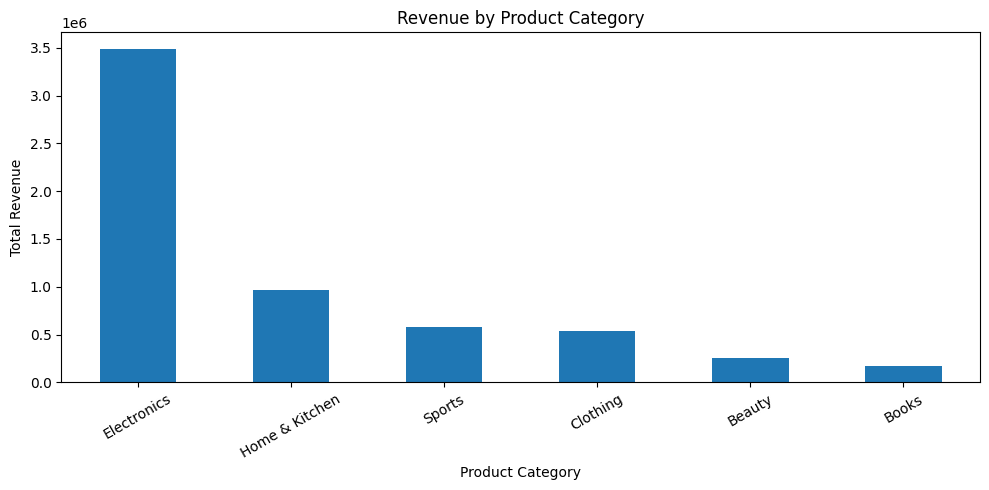

In [19]:
plt.figure(figsize=(10, 5))

category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [20]:
best_category = category_sales.idxmax()
best_category_revenue = category_sales.max()

print("Best Performing Category:", best_category)
print("Revenue:", round(best_category_revenue, 2))

Best Performing Category: Electronics
Revenue: 3487238.0


**Monthly Sales Analysis:**

In [21]:
monthly_sales = (
    df.groupby("Month")["Total_Amount"]
    .sum()
    .sort_index()
)

print(monthly_sales)

Month
2025-01    636776.5
2025-02    392408.5
2025-03    448029.5
2025-04    427069.5
2025-05    499988.5
2025-06    383381.0
2025-07    535944.0
2025-08    664651.5
2025-09    459390.0
2025-10    452574.0
2025-11    555415.0
2025-12    549456.5
Name: Total_Amount, dtype: float64


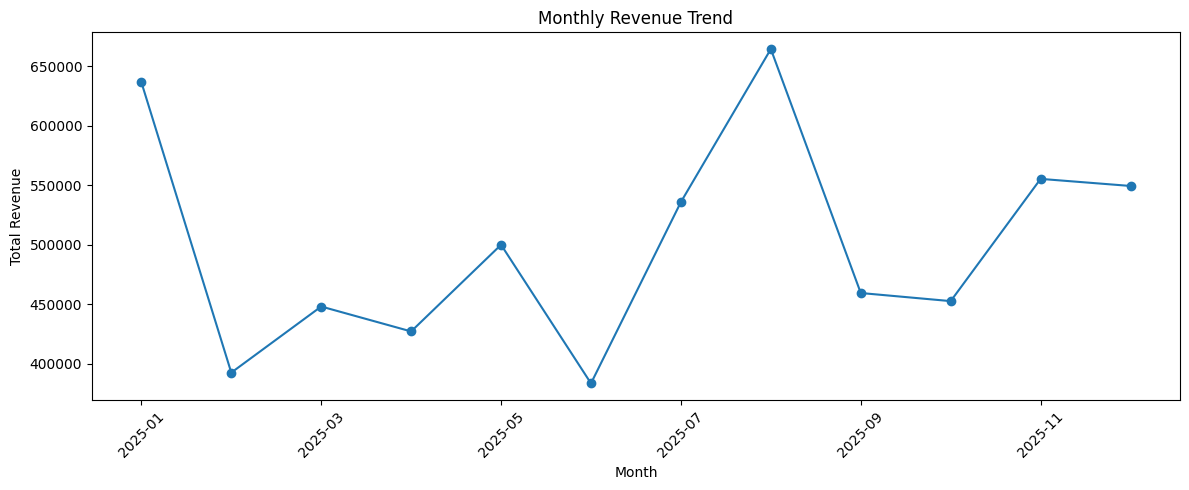

In [22]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
best_month = monthly_sales.idxmax()
best_month_revenue = monthly_sales.max()

print("Best Sales Month:", best_month)
print("Revenue:", round(best_month_revenue, 2))

Best Sales Month: 2025-08
Revenue: 664651.5


**Top 10 Products Analysis:**

In [24]:
top_products = (
    df.groupby("Product")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product
Smart Watch            784617.0
Power Bank             649502.5
Mouse                  566292.5
Keyboard               558476.0
Wireless Headphones    491187.0
Bluetooth Speaker      437163.0
Mixer Grinder          199327.0
Water Bottle           166509.0
Storage Box            162041.5
Bedsheet               157340.0
Name: Total_Amount, dtype: float64


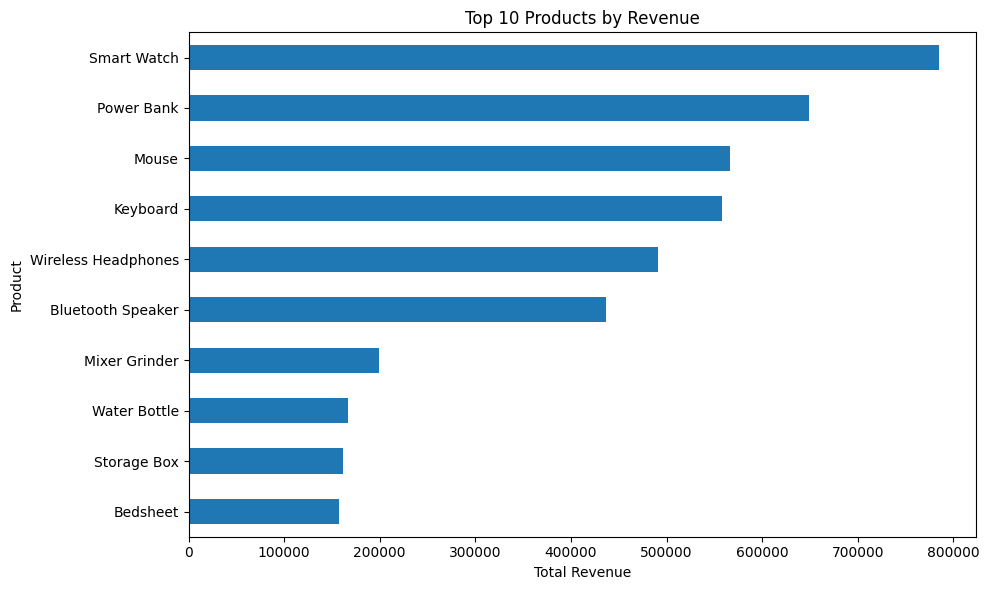

In [25]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [26]:
best_product = top_products.idxmax()
best_product_revenue = top_products.max()

print("Top Product:", best_product)
print("Revenue:", round(best_product_revenue, 2))

Top Product: Smart Watch
Revenue: 784617.0


**City-wise Sales Analysis:**

In [27]:
city_sales = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales)

City
Mumbai       1063843.5
Kolkata       676732.0
Jaipur        664107.0
Pune          626513.0
Delhi         577227.0
Ahmedabad     574986.5
Bengaluru     494457.5
Lucknow       494368.5
Chennai       482353.5
Hyderabad     350496.0
Name: Total_Amount, dtype: float64


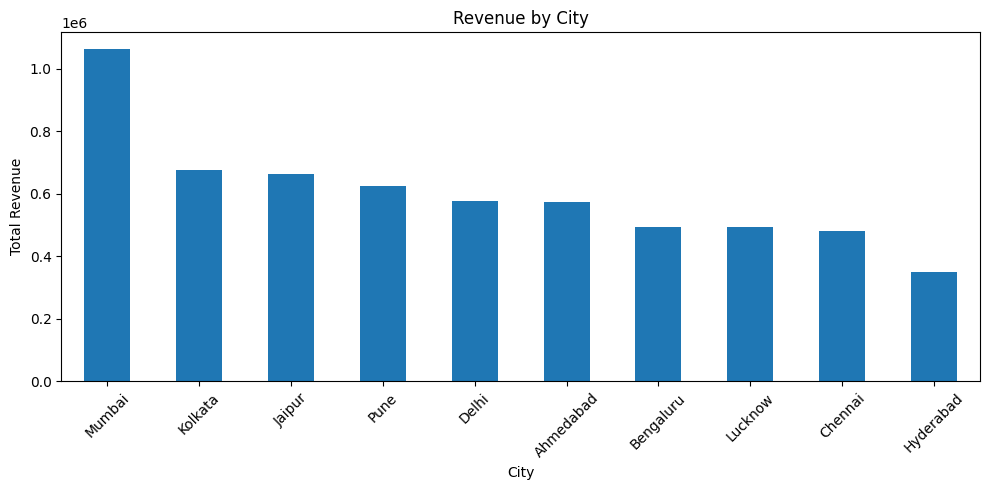

In [28]:
plt.figure(figsize=(10, 5))

city_sales.plot(kind="bar")

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
best_city = city_sales.idxmax()
best_city_revenue = city_sales.max()

print("Highest Revenue City:", best_city)
print("Revenue:", round(best_city_revenue, 2))

Highest Revenue City: Mumbai
Revenue: 1063843.5


**Payment Method Analysis:**

In [30]:
payment_counts = df["Payment_Method"].value_counts()

print(payment_counts)

Payment_Method
UPI                 220
Debit Card          204
Credit Card         201
Net Banking         193
Cash on Delivery    182
Name: count, dtype: int64


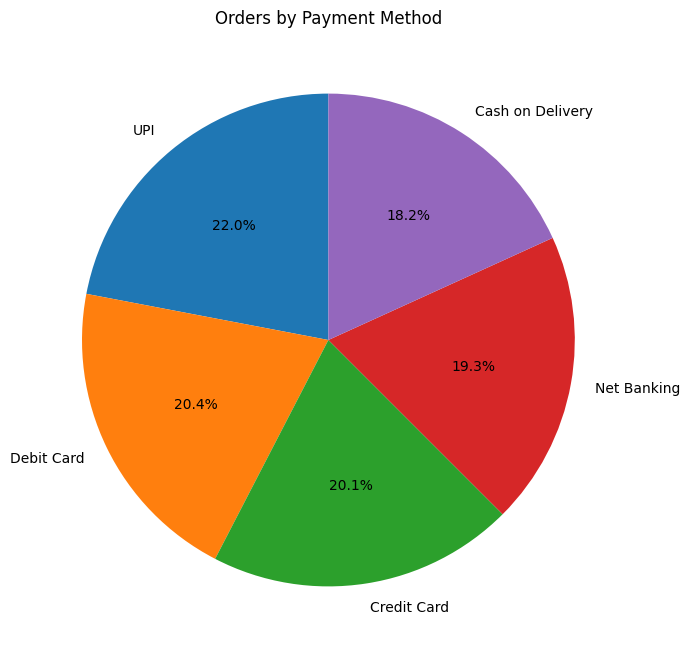

In [31]:
plt.figure(figsize=(8, 8))

payment_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Orders by Payment Method")
plt.ylabel("")

plt.show()

**Payment Method Analysis:**

In [32]:
most_used_payment = payment_counts.idxmax()
most_used_payment_count = payment_counts.max()

print("Most Used Payment Method:", most_used_payment)
print("Number of Orders:", most_used_payment_count)

Most Used Payment Method: UPI
Number of Orders: 220


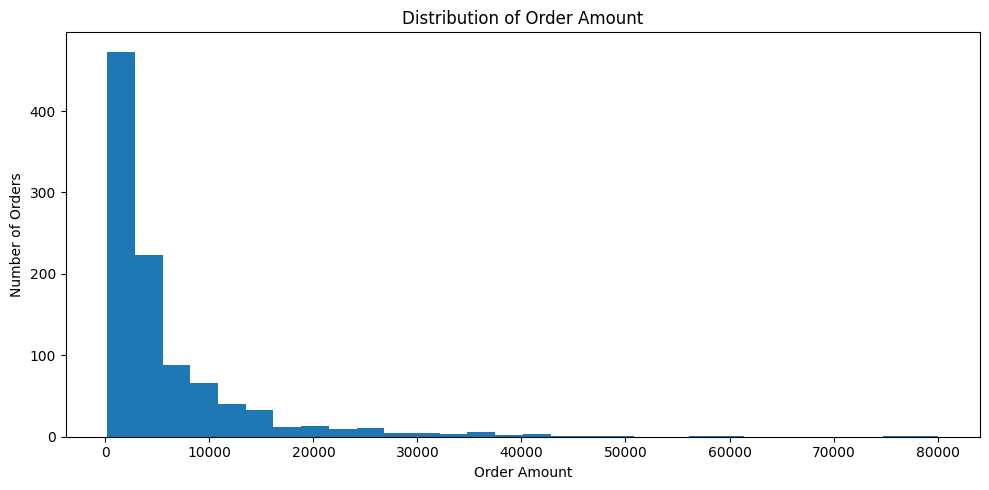

In [33]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Total_Amount"],
    bins=30
)

plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

**Gender-wise Sales Analysis:**

In [34]:
gender_sales = (
    df.groupby("Gender")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(gender_sales)

Gender
Male      3012464.5
Female    2992620.0
Name: Total_Amount, dtype: float64


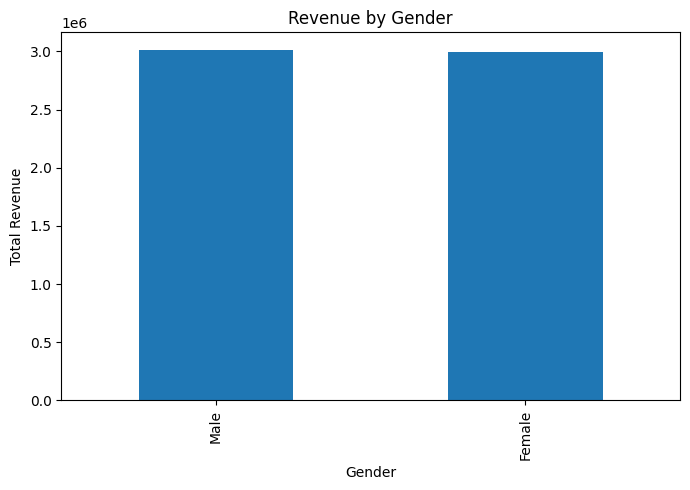

In [35]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind="bar")

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

**Order Status Analysis:**

In [36]:
status_counts = df["Order_Status"].value_counts()

print(status_counts)

Order_Status
Delivered    599
Cancelled    213
Returned     188
Name: count, dtype: int64


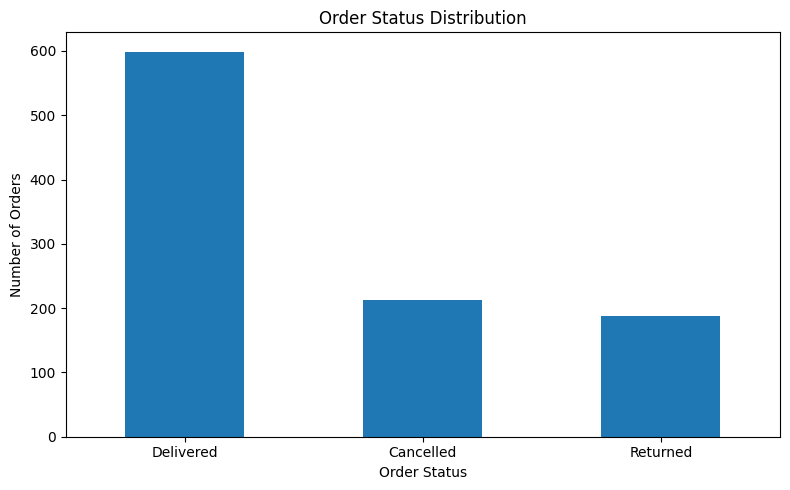

In [37]:
plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Correlation Analysis**

In [38]:
numeric_columns = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Total_Amount"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

                       Age  Quantity  Unit_Price  Discount_Percent  \
Age               1.000000  0.000821   -0.028987         -0.037332   
Quantity          0.000821  1.000000   -0.011057          0.012156   
Unit_Price       -0.028987 -0.011057    1.000000          0.050734   
Discount_Percent -0.037332  0.012156    0.050734          1.000000   
Total_Amount     -0.008051  0.420756    0.772822         -0.025752   

                  Total_Amount  
Age                  -0.008051  
Quantity              0.420756  
Unit_Price            0.772822  
Discount_Percent     -0.025752  
Total_Amount          1.000000  


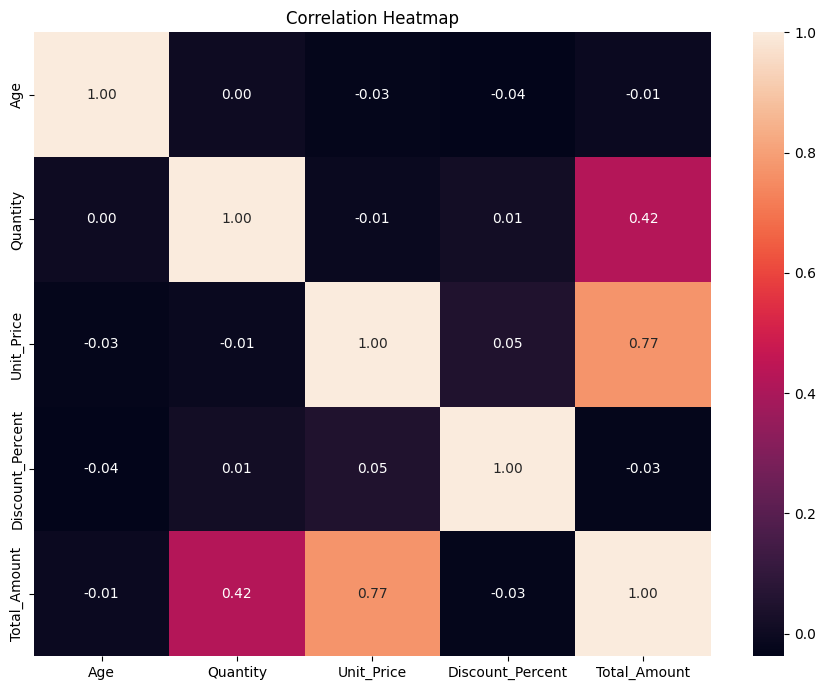

In [39]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [40]:
category_quantity = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print(category_quantity)

Category
Electronics       415
Clothing          314
Home & Kitchen    308
Books             228
Beauty            215
Sports            207
Name: Quantity, dtype: int64


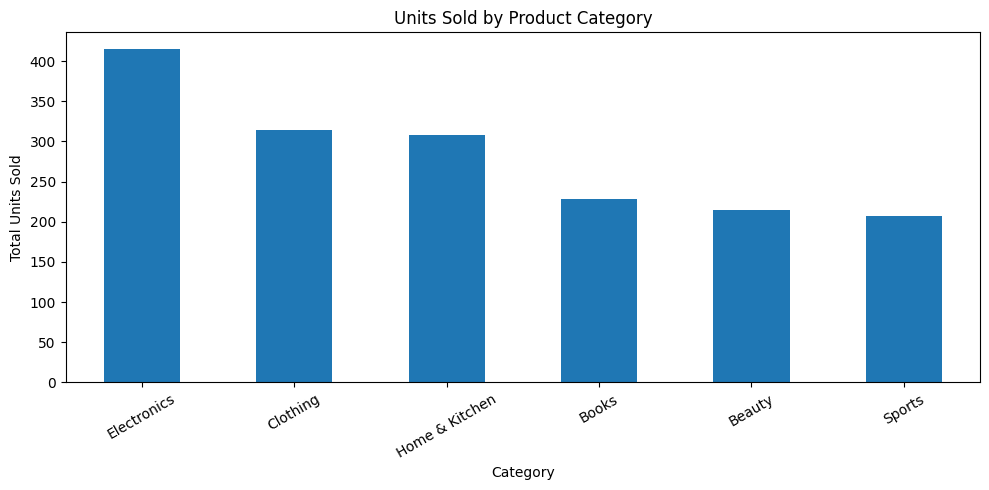

In [41]:
plt.figure(figsize=(10, 5))

category_quantity.plot(kind="bar")

plt.title("Units Sold by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [42]:
best_category = category_sales.idxmax()

print("Highest Revenue Category:", best_category)

Highest Revenue Category: Electronics


**Business Insight**

In [43]:
print("========== BUSINESS INSIGHTS ==========\n")

print("1. Highest Revenue Category:")
print(best_category)

print("\n2. Best Sales Month:")
print(best_month)

print("\n3. Top Revenue-Generating Product:")
print(best_product)

print("\n4. Highest Revenue City:")
print(best_city)

print("\n5. Most Used Payment Method:")
print(most_used_payment)

print("\n6. Total Orders:")
print(total_orders)

print("\n7. Total Revenue:")
print("₹", round(total_revenue, 2))

print("\n8. Average Order Value:")
print("₹", round(average_order_value, 2))

print("\n9. Total Units Sold:")
print(total_units)

print("\n========================================")

========== BUSINESS INSIGHTS ==========

1. Highest Revenue Category:
Electronics

2. Best Sales Month:
2025-08

3. Top Revenue-Generating Product:
Smart Watch

4. Highest Revenue City:
Mumbai

5. Most Used Payment Method:
UPI

6. Total Orders:
1000

7. Total Revenue:
₹ 6005084.5

8. Average Order Value:
₹ 6005.08

9. Total Units Sold:
1687



## Conclusion

The Online Shopping Sales Data Analysis project successfully demonstrates how Python can be used for data handling, exploratory data analysis, and visualization.

The analysis helped identify the highest-performing product category, top products, best-performing cities, monthly sales trends, customer payment preferences, and order status distribution.

Pandas was used for data cleaning, manipulation, grouping, and statistical analysis, while Matplotlib and Seaborn were used to create meaningful visualizations.

The project shows how raw sales data can be transformed into useful business insights that can support decision-making related to sales, marketing, inventory, and customer behavior.

**Exporting Dataset**

In [44]:
df.to_csv("online_shopping_sales.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [45]:
from google.colab import files

files.download("online_shopping_sales.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
print("Final Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Final Dataset Shape: (1000, 14)

Columns:
['Order_ID', 'Order_Date', 'City', 'Gender', 'Age', 'Category', 'Product', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Amount', 'Payment_Method', 'Order_Status', 'Month']

First 5 Records:


,Order_ID,Order_Date,City,Gender,Age,Category,Product,Quantity,Unit_Price,Discount_Percent,Total_Amount,Payment_Method,Order_Status,Month
0,ORD0001,2025-02-22,Jaipur,Male,55,Beauty,Face Wash,2,800,5,1520.0,Cash on Delivery,Delivered,2025-02
1,ORD0002,2025-04-12,Jaipur,Female,32,Electronics,Smart Watch,1,11110,20,8888.0,Cash on Delivery,Returned,2025-04
2,ORD0003,2025-06-24,Hyderabad,Male,31,Clothing,T-Shirt,2,890,15,1513.0,Debit Card,Delivered,2025-06
3,ORD0004,2025-01-23,Ahmedabad,Male,42,Electronics,Wireless Headphones,1,6650,10,5985.0,UPI,Returned,2025-01
4,ORD0005,2025-04-09,Delhi,Male,32,Clothing,Hoodie,2,3070,20,4912.0,Debit Card,Delivered,2025-04


## Project Summary

### Project Title
Online Shopping Sales Data Analysis Using Python

### Dataset
1000 online shopping transactions

### Main Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Main Areas of Analysis
- Sales KPIs
- Category-wise sales
- Monthly sales
- Top products
- City-wise revenue
- Payment methods
- Order status
- Gender-wise sales
- Correlation analysis

### Key Outcome
The project provides a complete data analysis workflow starting from data generation and cleaning to visualization and business insights.